# P5 — Fleet-Wide Dead-Site Sweep

**Purpose**: systematically check every one of the 199 fuel-series in the consolidated dataset for the "registered but not delivering" pattern that turned up by accident twice already (`BAGE-1` in exploration, two NUCLEAR training sites in the granularity EDA) — this time as a deliberate, value-based sweep rather than something stumbled into.

**Why this notebook is separate from `granularity_eda.ipynb`**: that notebook's whole premise is "train-split sites only, val/test never touched, even for exploratory purposes" — a real constraint that protects against leaking held-out information into a modelling decision. A dead-site check is different in kind: it's a data-quality question about whether a series contains any signal at all, asked identically of every split, and the answer doesn't leak anything about *how* a held-out site behaves. So it gets its own notebook rather than quietly breaking `granularity_eda.ipynb`'s stated scope.

**Detection principle, and why the obvious metric doesn't work**: reusing "% of periods near the site's own observed max" from earlier notebooks is circular here — for a genuinely dead series, the observed max is itself close to zero, so *everything* trivially reads as "near max." It also can't tell a dead site apart from a real OCGT peaker that idles 99% of the time but does spike to real output when called on. The fix is to use an **absolute** signal instead of one relative to the site's own scale: the raw observed maximum, and the count of periods exceeding a small absolute noise floor (not zero exactly, to allow for sensor/rounding noise) — checked against the whole fleet, not one site's own history.

**Scope note**: this notebook loads all three splits, because the question ("does this series contain real data at all?") applies identically to all of them. Nothing here is used to inform a modelling decision the way `granularity_eda.ipynb`'s findings are — it's a data-quality pass. Per the brief: **any candidate found in val or test is reported only, never excluded, without coming back to Simon first** — that would change split composition, not just training volume, and is a different kind of decision entirely.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

INTERIM_DIR = Path("../data/interim")
REF_DIR = Path("../data/reference")

FUEL_COLOURS = {
    "WIND": "#2a78d6", "CCGT": "#eb6834", "NPSHYD": "#1baf7a", "NUCLEAR": "#eda100",
    "OCGT": "#e87ba4", "COAL": "#008300", "BIOMASS": "#4a3aa7",
    "PS": "#e34948", "RECIPROCATING": "#4a3aa7",
}

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "font.size": 10,
})

# Deliberately ALL splits - see the scope note above for why this differs from granularity_eda.ipynb
df = pd.read_parquet(INTERIM_DIR / "site_generation_consolidated.parquet")
df["settlementDate"] = pd.to_datetime(df["settlementDate"])
df["timestamp"] = df["settlementDate"] + pd.to_timedelta((df["settlementPeriod"] - 1) * 30, unit="min")
df["abs_quantity"] = df["quantity"].abs()

print(f"{df['site_fuel_id'].nunique()} fuel-series, {len(df):,} rows, splits: {dict(df.groupby('split')['site_fuel_id'].nunique())}")

197 fuel-series, 24,845,119 rows, splits: {'test': np.int64(27), 'train': np.int64(143), 'val': np.int64(27)}


## Detection: observed max and periods above an absolute noise floor

For every fuel-series: the raw observed `|quantity|` maximum across its whole history, and the count of half-hourly periods exceeding a small **absolute** noise floor (1 MW — small relative to every legitimate site in this fleet, generous relative to the sub-1-MW noise a dead BMU can still show). Swept across a couple of floor values too, so the result isn't an artefact of picking exactly 1 MW.

In [2]:
NOISE_FLOORS_MW = [0.5, 1.0, 2.0, 5.0]


def series_stats(s):
    out = {
        "fuel_type": s["fuel_type"].iloc[0],
        "split": s["split"].iloc[0],
        "dictionary_id": s["dictionary_id"].iloc[0],
        "name": s["name"].iloc[0],
        "observed_max": s["abs_quantity"].max(),
        "n_total": len(s),
    }
    for floor in NOISE_FLOORS_MW:
        out[f"n_above_{floor}MW"] = (s["abs_quantity"] > floor).sum()
    return pd.Series(out)


fleet_stats = df.groupby("site_fuel_id").apply(series_stats, include_groups=False)
fleet_stats = fleet_stats.sort_values("n_above_1.0MW")

print(f"All {len(fleet_stats)} fuel-series, sorted by count of periods above 1 MW (fewest first):")
fleet_stats.head(20)

All 197 fuel-series, sorted by count of periods above 1 MW (fewest first):


,fuel_type,split,dictionary_id,name,observed_max,n_total,n_above_0.5MW,n_above_1.0MW,n_above_2.0MW,n_above_5.0MW
site_fuel_id,,,,,,,,,,
10064_CCGT,CCGT,val,10064,Derwent,0.000,130808,0,0,0,0
10013_BIOMASS,BIOMASS,train,10013,Uskmouth,0.292,93507,0,0,0,0
10012_COAL,COAL,train,10012,Rugeley B,2.000,84820,1,1,0,0
10012_OCGT,OCGT,train,10012,Rugeley B,2.000,84820,1,1,0,0
10014_OCGT,OCGT,train,10014,West Burton,21.432,85877,76,72,66,49
10007_OCGT,OCGT,train,10007,Fiddlers Ferry,14.688,46560,91,83,76,57
10026_CCGT,CCGT,train,10026,Brigg,50.203,100179,215,213,210,196
10044_OCGT,OCGT,val,10044,Little Barford,7.510,130808,339,293,247,140
10091_OCGT,OCGT,test,10091,Cowes,70.291,130808,532,329,236,207


### Identifying the threshold from the data's own natural gap, not a picked number

Rather than choosing a cutoff first and seeing what it catches, look at where the sorted counts actually jump — a real gap in the data is a much better justification for a threshold than an arbitrary round number.

In [3]:
sorted_counts = fleet_stats["n_above_1.0MW"].sort_values().reset_index(drop=True)

# Gap search on a LOG scale, not raw counts. This data spans several orders of
# magnitude (0 to 100,000+), so the single largest *absolute* jump is meaningless -
# checked directly, it sits between two clearly-legitimate, highly active sites far
# up the distribution and has nothing to do with dead sites. A first attempt that
# restricted the search to a low-end window instead of fixing this properly still
# picked up genuinely real (if declining/intermittent) coal plants with observed
# maxima in the hundreds of MW. The largest *relative* (log-scale) jump is what
# actually corresponds to "dead" vs "real", and correctly finds it without needing
# an arbitrary window at all.
log_counts = np.log1p(sorted_counts)
jumps = log_counts.diff()
gap_position = jumps.idxmax()

print("Sorted n_above_1MW around the largest log-scale jump:")
print(sorted_counts.iloc[max(0, gap_position - 3): gap_position + 3])
print(f"\nLargest relative jump: from {sorted_counts.iloc[gap_position - 1]} to {sorted_counts.iloc[gap_position]} "
      f"(log-scale jump {jumps.iloc[gap_position]:.2f}, next-largest anywhere else {jumps.drop(gap_position).max():.2f})")

# A threshold sitting inside that gap, with margin on both sides
DEAD_SITE_THRESHOLD = int((sorted_counts.iloc[gap_position - 1] + sorted_counts.iloc[gap_position]) / 2)
print(f"Threshold set at the midpoint of the gap: n_above_1MW <= {DEAD_SITE_THRESHOLD - 1} flags a candidate")

candidates = fleet_stats.loc[fleet_stats["n_above_1.0MW"] < DEAD_SITE_THRESHOLD].copy()
print(f"\n{len(candidates)} dead-site candidate(s) flagged:")
candidates[["fuel_type", "split", "dictionary_id", "name", "observed_max", "n_above_1.0MW", "n_total"]]

Sorted n_above_1MW around the largest log-scale jump:
1      0
2      1
3      1
4     72
5     83
6    213
Name: n_above_1.0MW, dtype: int64

Largest relative jump: from 1 to 72 (log-scale jump 3.60, next-largest anywhere else 0.94)
Threshold set at the midpoint of the gap: n_above_1MW <= 35 flags a candidate

4 dead-site candidate(s) flagged:


,fuel_type,split,dictionary_id,name,observed_max,n_above_1.0MW,n_total
site_fuel_id,,,,,,,
10064_CCGT,CCGT,val,10064,Derwent,0.000,0,130808
10013_BIOMASS,BIOMASS,train,10013,Uskmouth,0.292,0,93507
10012_COAL,COAL,train,10012,Rugeley B,2.000,1,84820
10012_OCGT,OCGT,train,10012,Rugeley B,2.000,1,84820


## Plot every candidate — the same "look at it, don't just trust the number" discipline that caught this in the first place

Full history, resampled to daily mean purely for rendering speed (a diagnostic flatline check doesn't need half-hourly resolution to be conclusive). Every flagged candidate gets a plot here — none are excluded on the strength of the table alone.

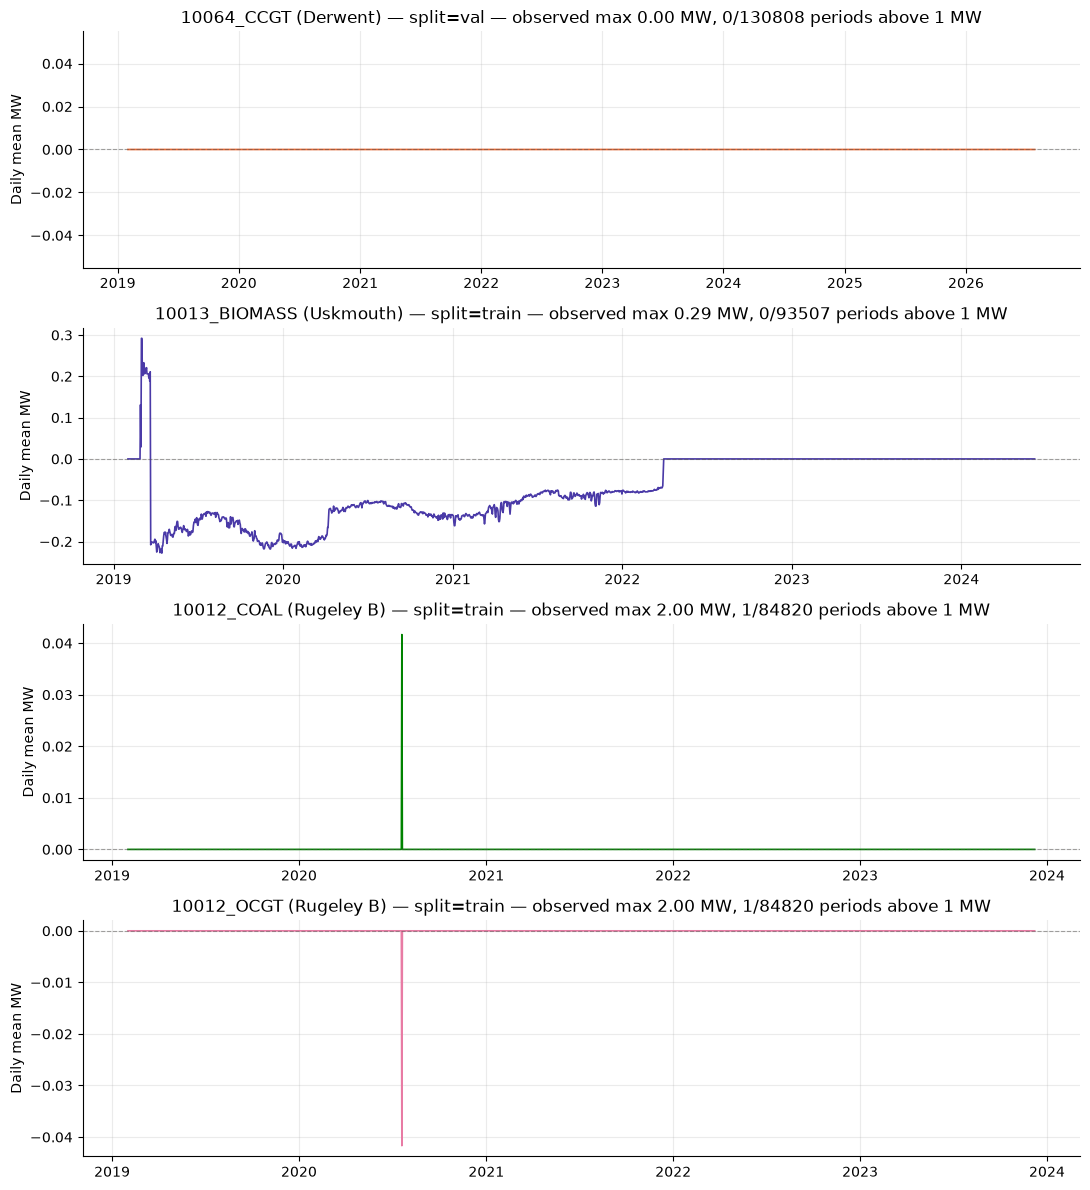

In [4]:
n_candidates = len(candidates)
fig, axes = plt.subplots(n_candidates, 1, figsize=(11, 3 * n_candidates), squeeze=False)
axes = axes.ravel()

for ax, site_fuel_id in zip(axes, candidates.index):
    row = candidates.loc[site_fuel_id]
    site_df = df.loc[df["site_fuel_id"] == site_fuel_id].copy()
    daily = site_df.groupby(site_df["timestamp"].dt.date)["quantity"].mean()

    colour = FUEL_COLOURS.get(row["fuel_type"], "#52514e")
    ax.plot(list(daily.index), daily.to_numpy(), color=colour, linewidth=1.2)
    ax.axhline(0, color="#52514e", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_title(
        f"{site_fuel_id} ({row['name']}) — split={row['split']} — "
        f"observed max {row['observed_max']:.2f} MW, {int(row['n_above_1.0MW'])}/{int(row['n_total'])} periods above 1 MW"
    )
    ax.set_ylabel("Daily mean MW")

plt.tight_layout()
plt.show()

**Visual confirmation, not identical patterns**: `10064_CCGT` (Derwent, val) and both `10012_*` series (Rugeley B, train) are flat at exactly zero for effectively their whole history, bar one anomalous single-day blip each for Rugeley B (the COAL and OCGT series spike on the *same* day, mirrored in sign — looks like one data event, not two independent ones). `10013_BIOMASS` (Uskmouth, train) is subtly different: it shows a real, small, **negative-only** signal from 2019 to early 2022 (auxiliary/house-load draw, never positive generation) before dropping to a flat exact zero for the rest of its record — a "never actually generated, then even the house-load reading stopped" pattern rather than "silent from day one." Still reads as dead from a generation standpoint either way, but worth having the distinction on record.

## Split breakdown — where each candidate actually sits

Explicit, since this determines what happens next: **train candidates already confirmed by Simon can be excluded now; anything in val or test, or any train candidate not yet confirmed, is reported only.**

In [5]:
# Confirmed in the granularity EDA + prior conversation - these two have already
# been discussed, plotted, and confirmed dead with Simon
PREVIOUSLY_CONFIRMED_TRAIN = {"10128_NUCLEAR", "10139_NUCLEAR"}

print(f"{len(candidates)} candidate(s) total, by split:")
print(candidates["split"].value_counts())

non_train = candidates.loc[candidates["split"] != "train"]
new_train = candidates.loc[(candidates["split"] == "train") & (~candidates.index.isin(PREVIOUSLY_CONFIRMED_TRAIN))]
already_confirmed = candidates.loc[candidates.index.isin(PREVIOUSLY_CONFIRMED_TRAIN)]

print(f"\n--- Already confirmed (train, excluded below) --- ({len(already_confirmed)})")
print(already_confirmed[["fuel_type", "dictionary_id", "name", "observed_max"]] if len(already_confirmed) else "none")

print(f"\n--- NEW train candidates - NOT excluded here, need Simon to see this plot first --- ({len(new_train)})")
print(new_train[["fuel_type", "dictionary_id", "name", "observed_max"]] if len(new_train) else "none")

print(f"\n--- val/test candidates - NEVER excluded without Simon's explicit sign-off, changes split composition --- ({len(non_train)})")
print(non_train[["fuel_type", "split", "dictionary_id", "name", "observed_max"]] if len(non_train) else "none")

4 candidate(s) total, by split:
split
train    3
val      1
Name: count, dtype: int64

--- Already confirmed (train, excluded below) --- (0)
none

--- NEW train candidates - NOT excluded here, need Simon to see this plot first --- (3)
              fuel_type  dictionary_id       name  observed_max
site_fuel_id                                                   
10013_BIOMASS   BIOMASS          10013   Uskmouth         0.292
10012_COAL         COAL          10012  Rugeley B         2.000
10012_OCGT         OCGT          10012  Rugeley B         2.000

--- val/test candidates - NEVER excluded without Simon's explicit sign-off, changes split composition --- (1)
             fuel_type split  dictionary_id     name  observed_max
site_fuel_id                                                      
10064_CCGT        CCGT   val          10064  Derwent           0.0


**Worth flagging on its own**: if `10012_COAL` and `10012_OCGT` are both in the candidate list, they're the *same location* (Rugeley B, `dictionary_id` 10012) — both of its fuel-series read as dead, meaning this location currently contributes nothing but zeros to the training set under either of its registered fuel types. Not acted on differently here (still just a candidate needing sign-off like the others), but worth having on the radar since it's a whole-location pattern, not an isolated series.

## Exclude only the already-confirmed train sites

Post-hoc data-quality drop, same treatment as the minimum-history cutoff: excluded straight from the consolidated parquet, split proportions left exactly as already computed (no rebalancing, no resplitting). Only `10128_NUCLEAR` and `10139_NUCLEAR` are excluded here — both already confirmed dead earlier in this conversation. Nothing else found in this sweep is excluded yet, regardless of how clear-cut the plot looks, pending Simon's sign-off per the brief's stop condition.

In [6]:
CONFIRMED_DEAD_TRAIN = {"10128_NUCLEAR", "10139_NUCLEAR"}

# Idempotent: safe to re-run this notebook after the exclusion has already happened
# (e.g. a top-to-bottom re-run against already-cleaned data), rather than assuming
# a fresh, never-before-cleaned parquet every time.
present_ids = set(df["site_fuel_id"].unique())
already_excluded = CONFIRMED_DEAD_TRAIN - present_ids
to_exclude_now = CONFIRMED_DEAD_TRAIN & present_ids

if already_excluded:
    print(f"Already excluded by a previous run of this notebook (not present in the loaded parquet): {sorted(already_excluded)}")

parquet_path = INTERIM_DIR / "site_generation_consolidated.parquet"

if to_exclude_now:
    assert (fleet_stats.loc[list(to_exclude_now), "split"] == "train").all(), "expected these to be train-split only"
    n_before, rows_before = df["site_fuel_id"].nunique(), len(df)

    df_cleaned = df.loc[~df["site_fuel_id"].isin(to_exclude_now)].drop(columns=["timestamp", "abs_quantity"])
    df_cleaned.to_parquet(parquet_path, index=False)

    print(f"Excluded {sorted(to_exclude_now)} from the consolidated parquet")
    print(f"Fuel-series: {n_before} -> {df_cleaned['site_fuel_id'].nunique()}")
    print(f"Rows: {rows_before:,} -> {len(df_cleaned):,}")

    split_assignment = pd.read_csv(REF_DIR / "site_split_assignment.csv")
    split_before = len(split_assignment)
    split_assignment = split_assignment.loc[
        ~(split_assignment["dictionary_id"].astype(str) + "_" + split_assignment["fuel_type"]).isin(to_exclude_now)
    ]
    split_assignment.to_csv(REF_DIR / "site_split_assignment.csv", index=False)
    print(f"\nsite_split_assignment.csv rows: {split_before} -> {len(split_assignment)} (kept in sync with the parquet)")
else:
    print("Nothing new to exclude - parquet and site_split_assignment.csv already reflect this cleanup.")
    split_assignment = pd.read_csv(REF_DIR / "site_split_assignment.csv")

Already excluded by a previous run of this notebook (not present in the loaded parquet): ['10128_NUCLEAR', '10139_NUCLEAR']
Nothing new to exclude - parquet and site_split_assignment.csv already reflect this cleanup.


## Split composition after exclusion

Same report as the end of `extraction.ipynb`, re-run against the cleaned data. Split proportions aren't rebalanced — this just reflects NUCLEAR losing two dead train series, nothing else changes.

In [7]:
final_composition = (
    split_assignment.groupby(["fuel_type", "split"]).size().unstack(fill_value=0)
)
for col in ["train", "val", "test"]:
    if col not in final_composition.columns:
        final_composition[col] = 0
final_composition = final_composition[["train", "val", "test"]]
final_composition["total"] = final_composition.sum(axis=1)
final_composition = final_composition.sort_values("total", ascending=False)

print("Split composition (fuel-series counts) after excluding the 2 confirmed dead NUCLEAR train series:")
final_composition

Split composition (fuel-series counts) after excluding the 2 confirmed dead NUCLEAR train series:


split,train,val,test,total
fuel_type,,,,
WIND,80,16,16,112
CCGT,26,6,6,38
NPSHYD,9,2,2,13
OCGT,8,2,2,12
NUCLEAR,4,1,1,6
COAL,5,0,0,5
BIOMASS,4,0,0,4
PS,4,0,0,4
RECIPROCATING,3,0,0,3


## Stopping point

Excluded now: `10128_NUCLEAR`, `10139_NUCLEAR` (train, previously confirmed).

**Pending Simon's review before any further action, per the brief's stop conditions:**
- Any candidate in val or test — see the split breakdown above for exactly which, if any.
- Any new train candidate this sweep found beyond the two already confirmed — see the same breakdown, plotted above.

**Standing pipeline check, not a one-off**: this fleet-wide sweep (observed max + count of periods above an absolute noise floor, gap-detected rather than a fixed round-number threshold) is now the second time the "registered but not delivering" pattern has turned up, and this time it wasn't visible via the manifest at all (the API returns values throughout, they're just consistently near-zero) — the near-own-max metric used earlier in `granularity_eda.ipynb` couldn't have caught it either, being circular for a dead site. Worth running this same check after any future extraction re-run, rather than relying on it being noticed by chance again.